In [71]:
import numpy as np 
import pandas as pd 

from sklearn.model_selection import train_test_split 

import matplotlib.pyplot as plt 
import seaborn as sns 

In [72]:
df = pd.read_csv('train.csv',usecols=['Fare','Age','Survived'])

In [73]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [74]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [75]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [76]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [77]:
X_train.head()

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458


In [78]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [79]:
X_train.head()

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0


In [80]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

# .values → converts a Pandas Series/DataFrame's data into a NumPy array.   # here we do not want index instead we want only values from right side , that's why we converted it into numpy array 

/var/folders/3s/ns8l4nq14cq62jr4rlgm2hv80000gn/T/ipykernel_4011/3173819957.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().s

In [81]:
X_train.sample(10)

,Age,Fare,Age_imputed
476,34.0,21.0000,34.0
360,40.0,27.9000,40.0
401,26.0,8.0500,26.0
871,47.0,52.5542,47.0
454,NaN,8.0500,7.0
222,51.0,8.0500,51.0
875,15.0,7.2250,15.0
362,45.0,14.4542,45.0
564,NaN,8.0500,20.0
432,42.0,26.0000,42.0


/var/folders/3s/ns8l4nq14cq62jr4rlgm2hv80000gn/T/ipykernel_4011/2022430605.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],label='original',hist=False)
/var/folders/3s/ns8l4nq14cq62jr4rlgm2hv80000gn/T/ipykernel_4011/2022430605.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5

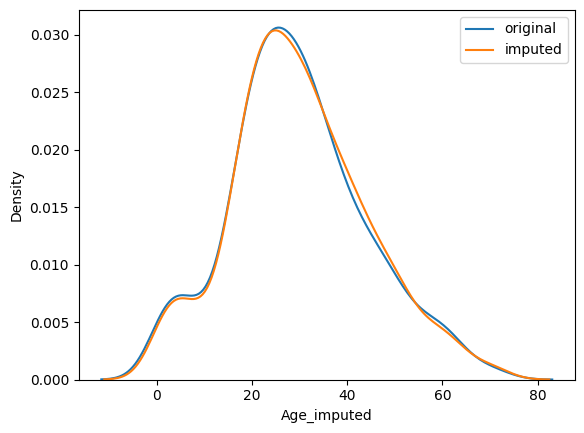

In [82]:
sns.distplot(X_train['Age'],label='original',hist=False)
sns.distplot(X_train['Age_imputed'],label='imputed',hist=False)

plt.legend()
plt.show()

In [ ]:

print("Original variable variance : ",X_train['Age'].var())
print("Imputed variable variance : ",X_train['Age_imputed'].var())
# there is not much differece which is so good but correleation with other column changes 
# if we choose mean filling instead of randomly filling then in final distplot it might happen that the peak of median increases but random different values are filled in Nan so distribution remain same  

Original variable variance :  204.3495133904614
Imputed variable variance :  202.0828852081655


In [ ]:
X_train[['Fare','Age','Age_imputed']].cov()
# too much difference in covariance 

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,62.956067
Age,71.512440,204.349513,204.349513
Age_imputed,62.956067,204.349513,202.082885


<Axes: >

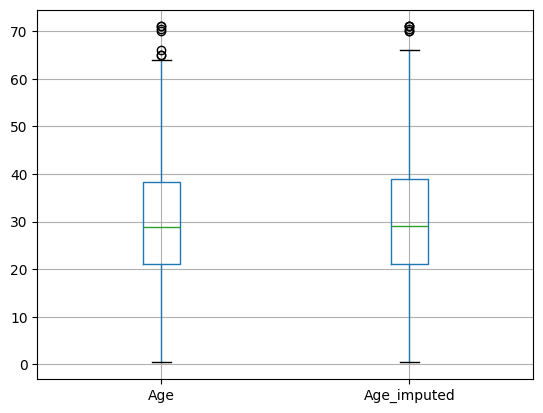

In [ ]:
X_train[['Age','Age_imputed']].boxplot()
# there is not too much impace on outliers 